In [1]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [2]:
# Setup NLTK for custom transform
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

In [3]:
# Load IRIS Dataset
iris = load_iris()
X = iris.data  # Features: Sepal length, Sepal width, Petal length, Petal width
y = iris.target # Labels: 0 (setosa), 1 (versicolor), 2 (virginica)

In [5]:
# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('clf', LogisticRegression(max_iter=200))
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

In [7]:
print("Logistic Regression Results: \n")
print(classification_report(y_test, lr_preds, target_names=iris.target_names))

Logistic Regression Results: 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
# Switching to SVC(kernel='rbf', C=1) pipeline
svc_pipeline = Pipeline([
    ('clf', SVC(kernel='rbf', C=1))
])

svc_pipeline.fit(X_train, y_train)
svc_preds = svc_pipeline.predict(X_test)

In [9]:
print("SVC (RBF Kernel) Results: \n")
print(classification_report(y_test, svc_preds, target_names=iris.target_names))

SVC (RBF Kernel) Results: 

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



VISUALIZATION OF DECISION BOUNDARIES FOR COMPARISON USING MATPLOTLIB AND NUMPY

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [11]:
# Load data using only the first two features for 2D plotting
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

In [12]:
# Define our two models
models = (
    LogisticRegression(max_iter=200),
    SVC(kernel='rbf', C=1)
)

In [13]:
# Fit both models
models = [clf.fit(X, y) for clf in models]

In [14]:
# Create a mesh grid for plotting
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

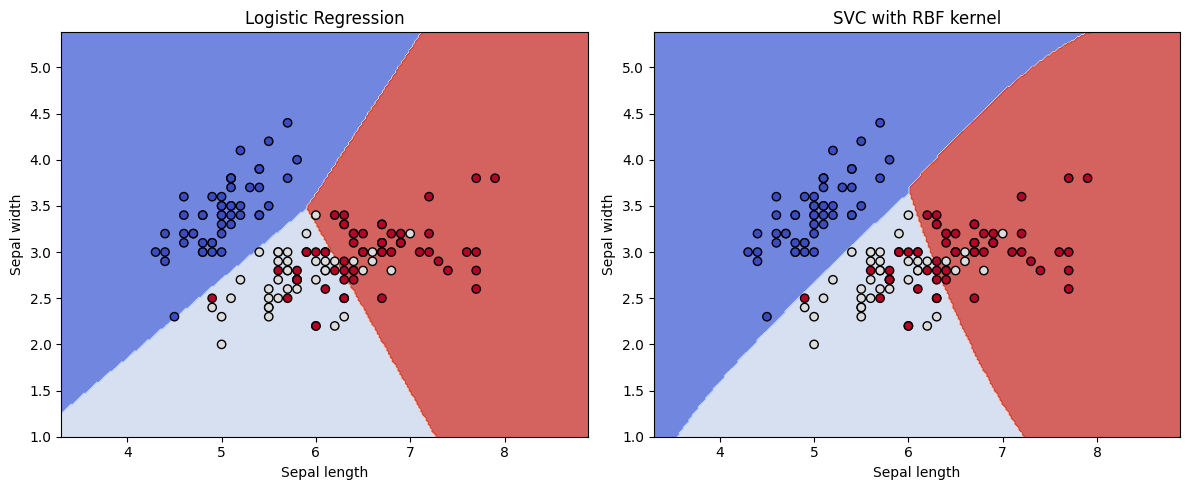

In [19]:
# Plotting
titles = ('Logistic Regression', 'SVC with RBF kernel')
fig, sub = plt.subplots(1, 2, figsize=(12, 5))

for clf, title, ax in zip(models, titles, sub.flatten()):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary (contour)
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Sepal length')
    ax.set_ylabel('Sepal width')

plt.tight_layout()
plt.show()